In [1]:
import importlib
import sys
import numpy as np
from collections import Counter
import pandas as pd

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

In [2]:
import event_log_loader.new_event_log_loader_v2
importlib.reload(event_log_loader.new_event_log_loader_v2)
from event_log_loader.new_event_log_loader_v2 import PrefixesDataFrameLoader, EventLogLoader

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(17)

event_log_location = '../../../../../../data/data/helpdesk.csv'

result_name = 'helpdesk_all'

# dynamic categorical attributes
cat_dynamic = ['Activity', 'Resource']

# static categorical attributes
# cat_static =  ['VariantIndex', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup']
cat_static =  ['VariantIndex', 'seriousness', 'customer', 'product', 'responsible_section', 'service_level', 'service_type', 'support_section', 'workgroup']
# cat_static = []

# dynamic numerical attributes
num_dynamic = ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']
num_dyn_log = []

# static numeric attributes
num_static = []

min_suffix_size = 5

# 15% test size:
test_validation_size = 0.15

event_log_properties = {# case id
                        'case_name' : 'CaseID',
                        # activity
                        'concept_name' : 'Activity',
                        # time values and computaitons
                        'timestamp_name' : 'CompleteTimestamp',
                        'date_format' : '%Y/%m/%d %H:%M:%S.%f',
                        'time_since_case_start_column' : 'case_elapsed_time',
                        'time_since_last_event_column' : 'event_elapsed_time',
                        'day_in_week_column' : 'day_in_week',
                        'seconds_in_day_column' : 'seconds_in_day',
                        # min suffix size for eos padding right
                        'min_suffix_size' : min_suffix_size,
                        # train and test split
                        # 'train_validation_size' : 0.15
                        'train_validation_size' : test_validation_size / (1-test_validation_size), # ensures that val used as cal set has same size as test set
                        'test_validation_size' :test_validation_size,
                        # window size for padding
                        'window_size' : 'auto',
                        # dynamic and static values
                        'categorical_columns' : cat_dynamic,
                        'static_categorical_columns' : cat_static,
                        'continuous_columns' : num_dynamic,
                        'continuous_positive_columns' : num_dyn_log,
                        'static_continuous_columns' : num_static}


## Create dataframes of prefixes

In [3]:
# object to create datframe of prefixes for petri-net repaly marking computation
pref_adopt_dataframe = PrefixesDataFrameLoader(event_log_location=event_log_location, event_log_properties=event_log_properties)

In [4]:
# output if necessary the raw dataframe: dynamic are lists, static values
raw_data = pref_adopt_dataframe.get_raw_dataframe()
raw_data

,CaseID,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,VariantIndex,seriousness,customer,product,responsible_section,service_level,service_type,support_section,workgroup
0,Case 1,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2, Value 1, Value 3]","[0.0, 44.0, 259959.0, 1371849.0, 2671462.0]","[nan, 44.0, 259915.0, 1111890.0, 1299613.0]","[1, 1, 4, 3, 4]","[53417, 53461, 54176, 42866, 46479]",12,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
1,Case 10,"[Assign seriousness, Take in charge ticket, Re...","[Value 2, Value 2, Value 2, Value 5]","[0.0, 3196606.0, 3196613.0, 4489038.0]","[nan, 3196606.0, 7.0, 1292425.0]","[2, 4, 4, 5]","[31820, 31626, 31633, 28058]",1,Value 1,Value 10,Value 3,Value 2,Value 3,Value 1,Value 2,Value 3
2,Case 100,"[Assign seriousness, Take in charge ticket, Re...","[Value 1, Value 9, Value 9, Value 2, Value 3]","[0.0, 1036724.0, 1056354.0, 2861743.0, 4157763.0]","[nan, 1036724.0, 19630.0, 1805389.0, 1296020.0]","[4, 2, 2, 2, 3]","[37517, 37441, 57071, 48060, 48080]",10,Value 1,Value 44,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
3,Case 1000,"[Assign seriousness, Assign seriousness, Take ...","[Value 2, Value 2, Value 2, Value 2, Value 5]","[0.0, 6.0, 12.0, 450805.0, 3802049.0]","[nan, 6.0, 6.0, 450793.0, 3351244.0]","[3, 3, 3, 1, 5]","[32008, 32014, 32020, 50813, 32457]",4,Value 1,Value 92,Value 3,Value 4,Value 2,Value 1,Value 3,Value 1
4,Case 1001,"[Assign seriousness, Take in charge ticket, Re...","[Value 4, Value 4, Value 4, Value 3]","[0.0, 1436829.0, 1704597.0, 2997012.0]","[nan, 1436829.0, 267768.0, 1292415.0]","[4, 0, 3, 4]","[61284, 29313, 37881, 34296]",1,Value 1,Value 239,Value 2,Value 1,Value 2,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4575,Case 995,"[Assign seriousness, Take in charge ticket, Wa...","[Value 8, Value 8, Value 6, Value 6, Value 6, ...","[0.0, 30.0, 90286.0, 3194141.0, 3194763.0, 449...","[nan, 30.0, 90256.0, 3103855.0, 622.0, 1296011.0]","[2, 2, 3, 4, 4, 5]","[31711, 31741, 35597, 29052, 29674, 29685]",3,Value 1,Value 9,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2
4576,Case 996,"[Assign seriousness, Take in charge ticket, Re...","[Value 8, Value 6, Value 6, Value 5]","[0.0, 325091.0, 1885211.0, 3181227.0]","[nan, 325091.0, 1560120.0, 1296016.0]","[3, 0, 4, 5]","[49903, 29394, 34314, 34330]",1,Value 1,Value 9,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2
4577,Case 997,"[Assign seriousness, Take in charge ticket, Re...","[Value 1, Value 13, Value 13, Value 5]","[0.0, 258637.0, 871435.0, 2851523.0]","[nan, 258637.0, 612798.0, 1980088.0]","[4, 0, 0, 2]","[48912, 48349, 56347, 49235]",1,Value 1,Value 233,Value 2,Value 1,Value 2,Value 1,Value 1,Value 1
4578,Case 998,"[Assign seriousness, Take in charge ticket, Wa...","[Value 9, Value 2, Value 9, Value 9, Value 3]","[0.0, 25.0, 338294.0, 1745662.0, 3041677.0]","[nan, 25.0, 338269.0, 1407368.0, 1296015.0]","[4, 4, 1, 3, 4]","[43033, 43058, 35727, 60695, 60710]",2,Value 1,Value 62,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1


In [5]:
# outputs for perturbations:
# train_df, val_df, test_df = pref_adopt_dataframe.get_all_datasets()
# categories = pref_adopt_dataframe.extract_feature_info()

In [6]:
# prefix dataset for potential marking computation
train_pref_df = pref_adopt_dataframe.get_dataset('train')
train_pref_df

,CaseID,prefix_length,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,VariantIndex,seriousness,customer,product,responsible_section,service_level,service_type,support_section,workgroup
0,Case 10,1,[Assign seriousness],[Value 2],[0.0],[nan],[2.0],[31820.0],1.0,Value 1,Value 10,Value 3,Value 2,Value 3,Value 1,Value 2,Value 3
1,Case 10,2,"[Assign seriousness, Take in charge ticket]","[Value 2, Value 2]","[0.0, 3196606.0]","[nan, 3196606.0]","[2.0, 4.0]","[31820.0, 31626.0]",1.0,Value 1,Value 10,Value 3,Value 2,Value 3,Value 1,Value 2,Value 3
2,Case 10,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 2, Value 2, Value 2]","[0.0, 3196606.0, 3196613.0]","[nan, 3196606.0, 7.0]","[2.0, 4.0, 4.0]","[31820.0, 31626.0, 31633.0]",1.0,Value 1,Value 10,Value 3,Value 2,Value 3,Value 1,Value 2,Value 3
3,Case 10,4,"[Assign seriousness, Take in charge ticket, Re...","[Value 2, Value 2, Value 2, Value 5]","[0.0, 3196606.0, 3196613.0, 4489038.0]","[nan, 3196606.0, 7.0, 1292425.0]","[2.0, 4.0, 4.0, 5.0]","[31820.0, 31626.0, 31633.0, 28058.0]",1.0,Value 1,Value 10,Value 3,Value 2,Value 3,Value 1,Value 2,Value 3
4,Case 100,1,[Assign seriousness],[Value 1],[0.0],[nan],[4.0],[37517.0],10.0,Value 1,Value 44,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14407,Case 993,6,"[Assign seriousness, Take in charge ticket, Wa...","[Value 8, Value 8, Value 2, Value 2, Value 2, ...","[0.0, 235.0, 1200632.0, 1379474.0, 1379486.0, ...","[nan, 235.0, 1200397.0, 178842.0, 12.0, 147825...","[0.0, 0.0, 0.0, 2.0, 2.0, 5.0]","[40283.0, 40518.0, 31315.0, 37357.0, 37369.0, ...",3.0,Value 1,Value 213,Value 2,Value 1,Value 2,Value 1,Value 1,Value 1
14408,Case 996,1,[Assign seriousness],[Value 8],[0.0],[nan],[3.0],[49903.0],1.0,Value 1,Value 9,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2
14409,Case 996,2,"[Assign seriousness, Take in charge ticket]","[Value 8, Value 6]","[0.0, 325091.0]","[nan, 325091.0]","[3.0, 0.0]","[49903.0, 29394.0]",1.0,Value 1,Value 9,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2
14410,Case 996,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 8, Value 6, Value 6]","[0.0, 325091.0, 1885211.0]","[nan, 325091.0, 1560120.0]","[3.0, 0.0, 4.0]","[49903.0, 29394.0, 34314.0]",1.0,Value 1,Value 9,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2


In [7]:
train_pref_df.to_csv('../../../../encoded_data_conformal/Helpdesk/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_train.csv', index=False)

In [8]:
# prefix dataset for potential marking computation
val_pref_df = pref_adopt_dataframe.get_dataset('val')
val_pref_df

,CaseID,prefix_length,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,VariantIndex,seriousness,customer,product,responsible_section,service_level,service_type,support_section,workgroup
0,Case 1,1,[Assign seriousness],[Value 1],[0.0],[nan],[1.0],[53417.0],12.0,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
1,Case 1,2,"[Assign seriousness, Take in charge ticket]","[Value 1, Value 1]","[0.0, 44.0]","[nan, 44.0]","[1.0, 1.0]","[53417.0, 53461.0]",12.0,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
2,Case 1,3,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2]","[0.0, 44.0, 259959.0]","[nan, 44.0, 259915.0]","[1.0, 1.0, 4.0]","[53417.0, 53461.0, 54176.0]",12.0,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
3,Case 1,4,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2, Value 1]","[0.0, 44.0, 259959.0, 1371849.0]","[nan, 44.0, 259915.0, 1111890.0]","[1.0, 1.0, 4.0, 3.0]","[53417.0, 53461.0, 54176.0, 42866.0]",12.0,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
4,Case 1,5,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2, Value 1, Value 3]","[0.0, 44.0, 259959.0, 1371849.0, 2671462.0]","[nan, 44.0, 259915.0, 1111890.0, 1299613.0]","[1.0, 1.0, 4.0, 3.0, 4.0]","[53417.0, 53461.0, 54176.0, 42866.0, 46479.0]",12.0,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3762,Case 998,5,"[Assign seriousness, Take in charge ticket, Wa...","[Value 9, Value 2, Value 9, Value 9, Value 3]","[0.0, 25.0, 338294.0, 1745662.0, 3041677.0]","[nan, 25.0, 338269.0, 1407368.0, 1296015.0]","[4.0, 4.0, 1.0, 3.0, 4.0]","[43033.0, 43058.0, 35727.0, 60695.0, 60710.0]",2.0,Value 1,Value 62,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
3763,Case 999,1,[Assign seriousness],[Value 1],[0.0],[nan],[1.0],[57997.0],1.0,Value 1,Value 92,Value 3,Value 1,Value 2,Value 2,Value 1,Value 4
3764,Case 999,2,"[Assign seriousness, Take in charge ticket]","[Value 1, Value 12]","[0.0, 1107043.0]","[nan, 1107043.0]","[1.0, 0.0]","[57997.0, 41840.0]",1.0,Value 1,Value 92,Value 3,Value 1,Value 2,Value 2,Value 1,Value 4
3765,Case 999,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 1, Value 12, Value 12]","[0.0, 1107043.0, 2593073.0]","[nan, 1107043.0, 1486030.0]","[1.0, 0.0, 3.0]","[57997.0, 41840.0, 59070.0]",1.0,Value 1,Value 92,Value 3,Value 1,Value 2,Value 2,Value 1,Value 4


In [9]:
val_pref_df.to_csv('../../../../encoded_data_conformal/Helpdesk/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_val.csv', index=False)

In [10]:
# prefix dataset for potential marking computation
test_pref_df = pref_adopt_dataframe.get_dataset('test')
test_pref_df

,CaseID,prefix_length,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,VariantIndex,seriousness,customer,product,responsible_section,service_level,service_type,support_section,workgroup
0,Case 1016,1,[Assign seriousness],[Value 8],[0.0],[nan],[2.0],[27781.0],1.0,Value 1,Value 8,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2
1,Case 1016,2,"[Assign seriousness, Take in charge ticket]","[Value 8, Value 8]","[0.0, 149.0]","[nan, 149.0]","[2.0, 2.0]","[27781.0, 27930.0]",1.0,Value 1,Value 8,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2
2,Case 1016,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 8, Value 8, Value 16]","[0.0, 149.0, 26072.0]","[nan, 149.0, 25923.0]","[2.0, 2.0, 2.0]","[27781.0, 27930.0, 53853.0]",1.0,Value 1,Value 8,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2
3,Case 1016,4,"[Assign seriousness, Take in charge ticket, Re...","[Value 8, Value 8, Value 16, Value 5]","[0.0, 149.0, 26072.0, 5098075.0]","[nan, 149.0, 25923.0, 5072003.0]","[2.0, 2.0, 2.0, 5.0]","[27781.0, 27930.0, 53853.0, 28256.0]",1.0,Value 1,Value 8,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2
4,Case 102,1,[Assign seriousness],[Value 4],[0.0],[nan],[0.0],[32969.0],1.0,Value 1,Value 62,Value 3,Value 1,Value 1,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3164,Case 995,6,"[Assign seriousness, Take in charge ticket, Wa...","[Value 8, Value 8, Value 6, Value 6, Value 6, ...","[0.0, 30.0, 90286.0, 3194141.0, 3194763.0, 449...","[nan, 30.0, 90256.0, 3103855.0, 622.0, 1296011.0]","[2.0, 2.0, 3.0, 4.0, 4.0, 5.0]","[31711.0, 31741.0, 35597.0, 29052.0, 29674.0, ...",3.0,Value 1,Value 9,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2
3165,Case 997,1,[Assign seriousness],[Value 1],[0.0],[nan],[4.0],[48912.0],1.0,Value 1,Value 233,Value 2,Value 1,Value 2,Value 1,Value 1,Value 1
3166,Case 997,2,"[Assign seriousness, Take in charge ticket]","[Value 1, Value 13]","[0.0, 258637.0]","[nan, 258637.0]","[4.0, 0.0]","[48912.0, 48349.0]",1.0,Value 1,Value 233,Value 2,Value 1,Value 2,Value 1,Value 1,Value 1
3167,Case 997,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 1, Value 13, Value 13]","[0.0, 258637.0, 871435.0]","[nan, 258637.0, 612798.0]","[4.0, 0.0, 0.0]","[48912.0, 48349.0, 56347.0]",1.0,Value 1,Value 233,Value 2,Value 1,Value 2,Value 1,Value 1,Value 1


In [11]:
test_pref_df.to_csv('../../../../encoded_data_conformal/Helpdesk/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_test.csv', index=False)

## Optional: Compute Petri Net replay markings of prefixes 

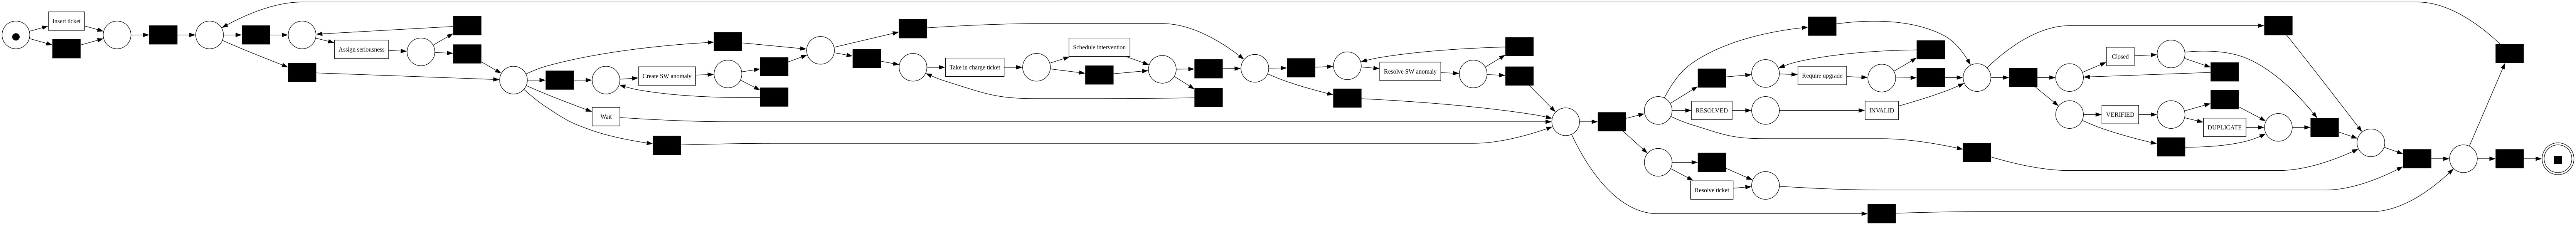

In [12]:
# Calculate and store markings:
import event_log_loader.petri_net_replay_markings
importlib.reload(event_log_loader.petri_net_replay_markings)
from event_log_loader.petri_net_replay_markings import InductiveMiner, PNReplayMarkings

# initialize the process 
miner = InductiveMiner(path_to_csv_log=event_log_location, case_id_col="CaseID", activity_col="Activity", timestamp_col="CompleteTimestamp", resource_col="Resource")
net, im, fm = miner.discover_petri_net(visulaize=True, store_loc_file_path='../../../../encoded_data_conformal/Helpdesk/prefix_for_replay/petri_net/helpdesk.png')

In [13]:
# train set markings
replayer_train = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=train_pref_df, event_label="Activity")

markings_train = replayer_train.get_markings_token_replay()

print("Amount markings: ", len(markings_train))
markings_counter_train = Counter(tuple(mark) for mark in markings_train)
markings_summary_train = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_train.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_train

Amount markings:  14412


,marking,count
0,[p_19],3439
1,"[p_26, p_25]",3315
2,[p_9],3305
3,"[p_25, p_38, p_36]",3085
4,[p_11],987
5,"[p_24, p_30]",79
6,[p_4],79
7,"[p_30, p_25]",57
8,[p_14],48
9,[p_22],9


In [14]:
# train set markings
replayer_val = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=val_pref_df, event_label="Activity")

markings_val = replayer_val.get_markings_token_replay()

print("Amount markings: ", len(markings_val))
markings_counter_val = Counter(tuple(mark) for mark in markings_val)
markings_summary_val = (pd.DataFrame([(list(mark), count) for mark, count in markings_counter_val.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_val

Amount markings:  3767


,marking,count
0,[p_19],881
1,[p_9],879
2,"[p_26, p_25]",861
3,"[p_25, p_38, p_36]",802
4,[p_11],264
5,"[p_24, p_30]",24
6,"[p_30, p_25]",17
7,[p_4],16
8,[p_14],12
9,[p_22],4


In [15]:
# train set markings
replayer_test = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=test_pref_df, event_label="Activity")

markings_test = replayer_test.get_markings_token_replay()

print("Amount markings: ", len(markings_test))
markings_counter_test = Counter(tuple(mark) for mark in markings_test)
markings_summary_test = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_test.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_test

Amount markings:  3169


,marking,count
0,[p_9],754
1,[p_19],740
2,"[p_26, p_25]",724
3,"[p_25, p_38, p_36]",685
4,[p_11],212
5,[p_4],23
6,"[p_24, p_30]",15
7,"[p_30, p_25]",8
8,[p_14],7
9,[p_18],1


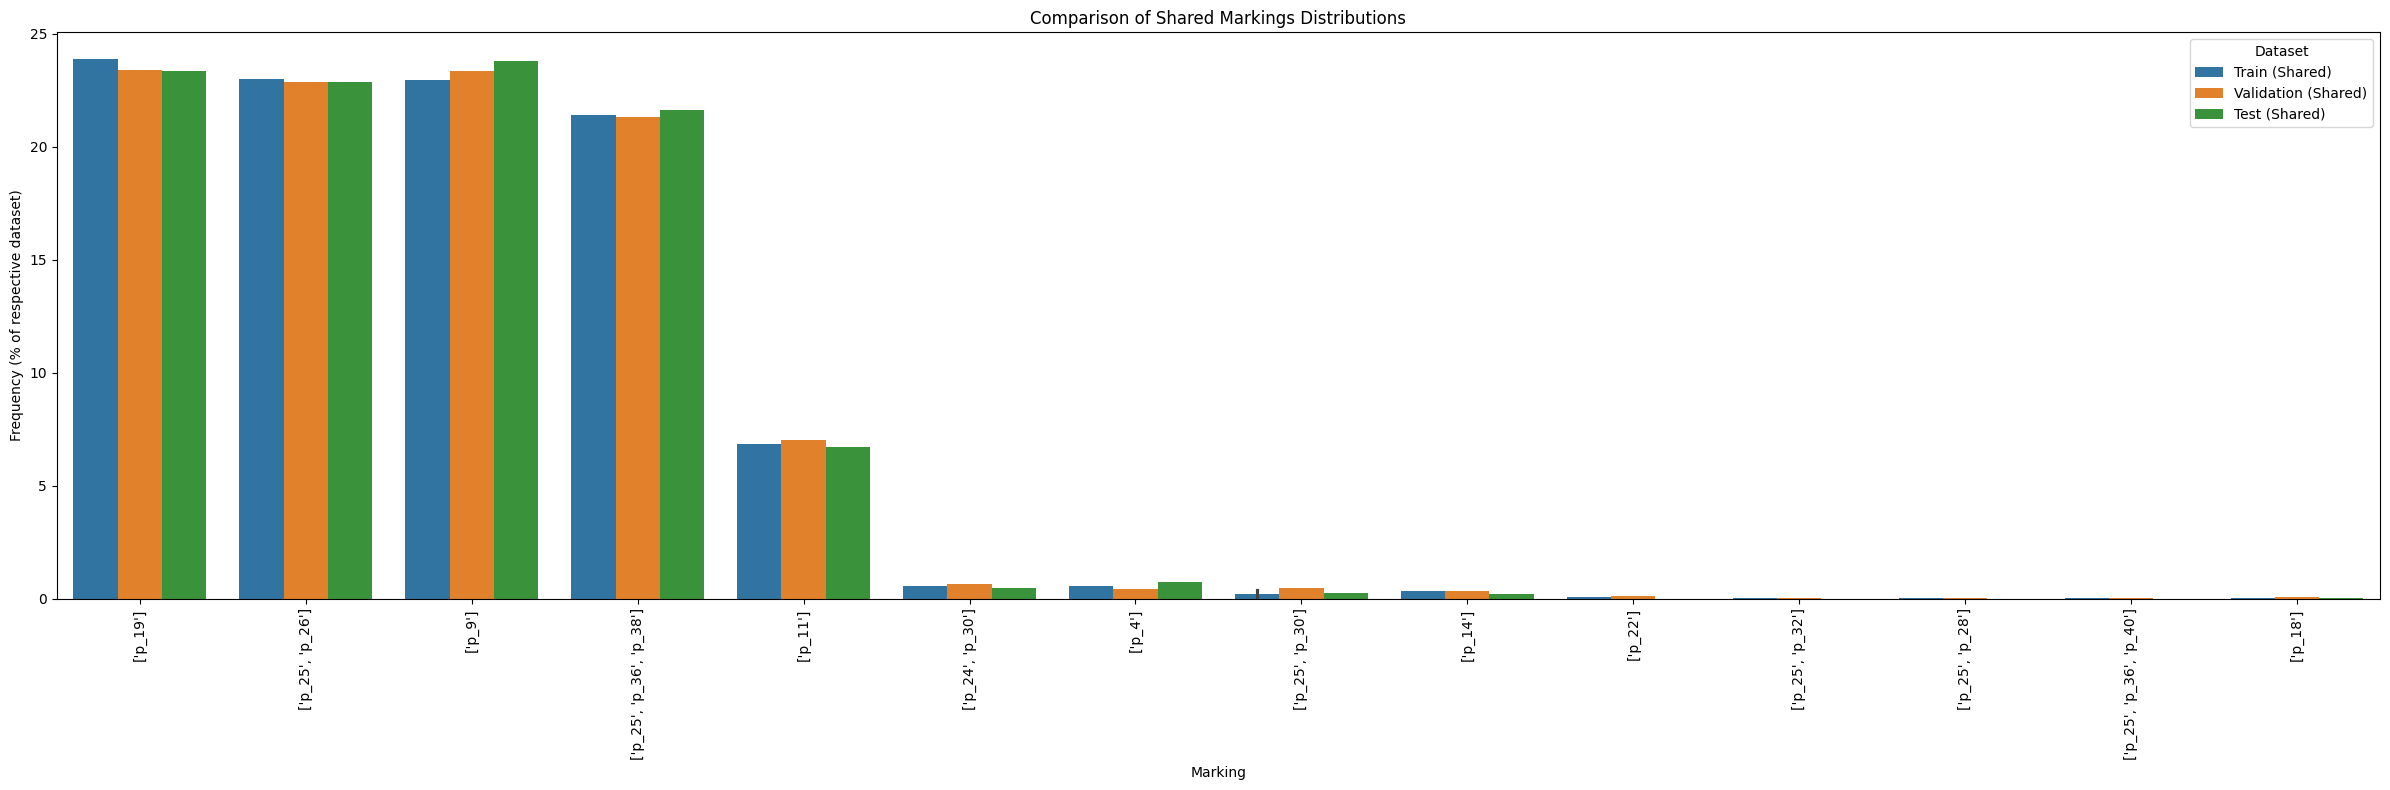

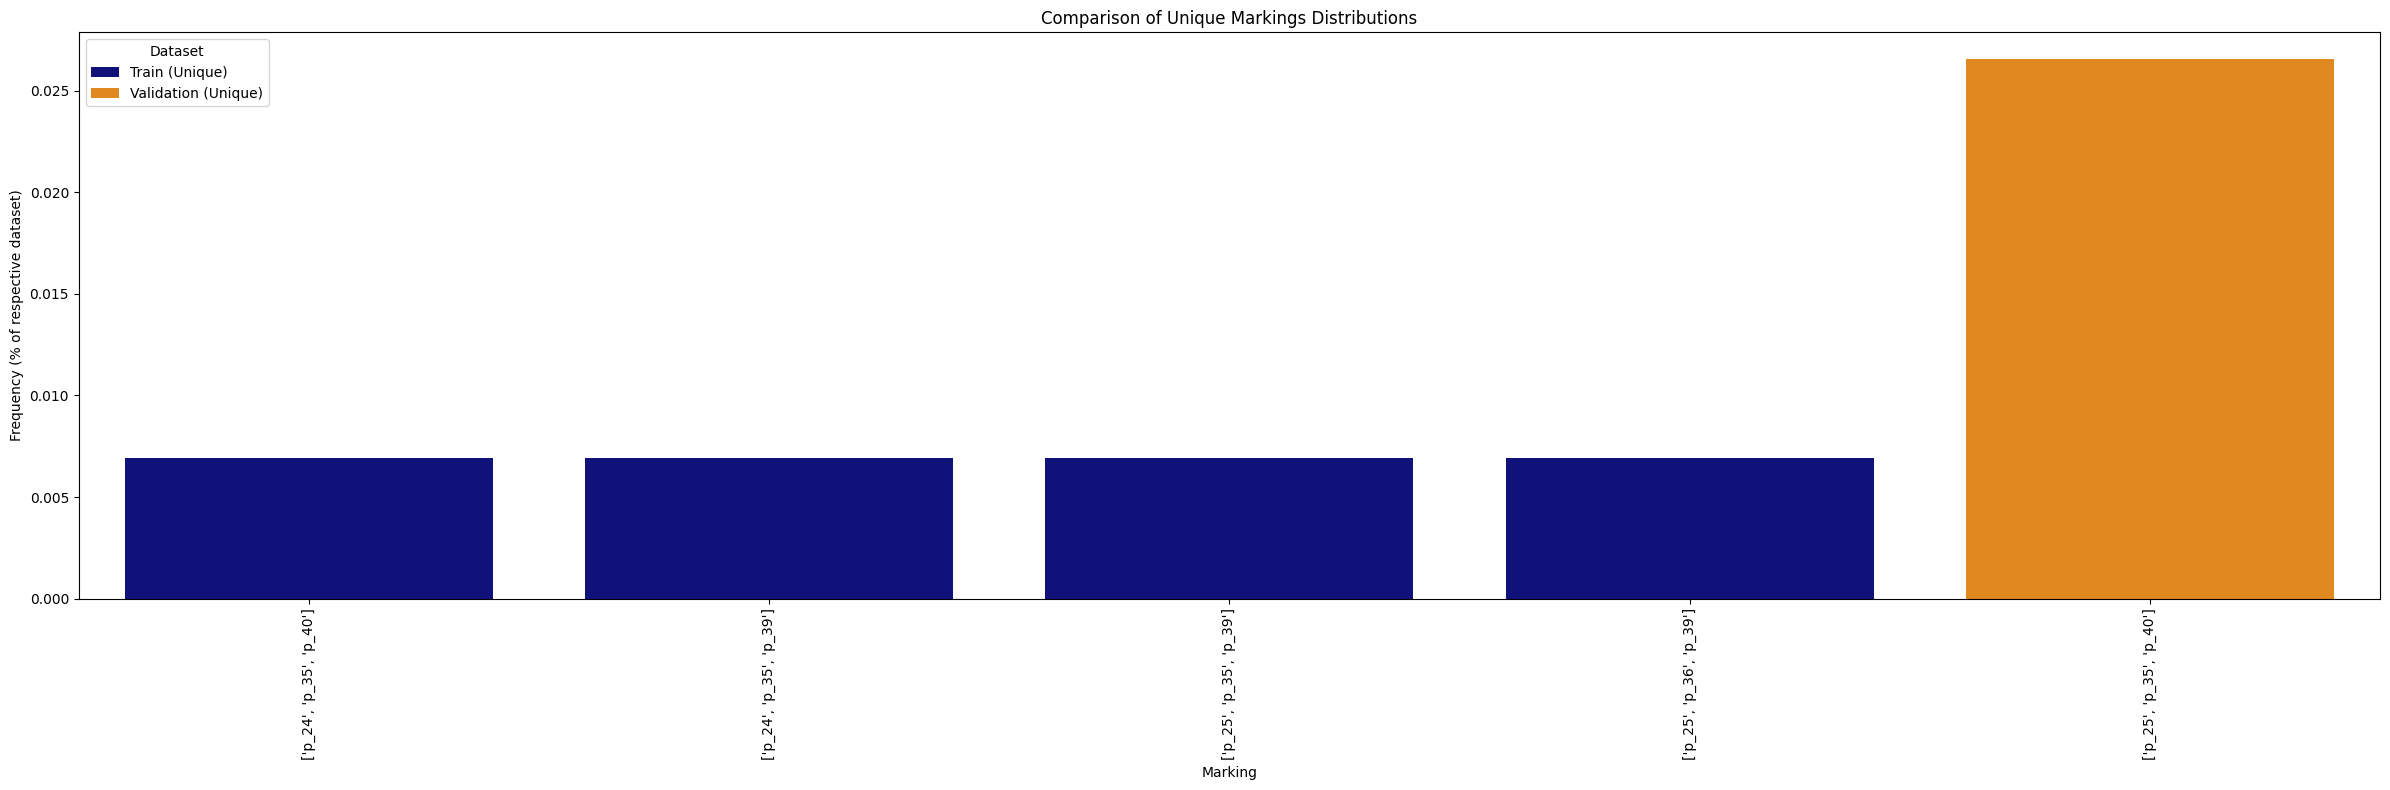

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Process train markings
markings_summary_train['marking_str'] = markings_summary_train['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_train['freq'] = (markings_summary_train['count'] / markings_summary_train['count'].sum()) * 100
markings_summary_train['dataset'] = 'Train'

# Process validation markings
markings_summary_val['marking_str'] = markings_summary_val['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_val['freq'] = (markings_summary_val['count'] / markings_summary_val['count'].sum()) * 100
markings_summary_val['dataset'] = 'Validation'

# Process test markings
markings_summary_test['marking_str'] = markings_summary_test['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_test['freq'] = (markings_summary_test['count'] / markings_summary_test['count'].sum()) * 100
markings_summary_test['dataset'] = 'Test'

# Combine
combined_markings = pd.concat([
    markings_summary_train[['marking_str', 'freq', 'dataset']],
    markings_summary_val[['marking_str', 'freq', 'dataset']], 
    markings_summary_test[['marking_str', 'freq', 'dataset']]
])

# Identify unique markings
train_markings = set(markings_summary_train['marking_str'])
val_markings = set(markings_summary_val['marking_str'])
test_markings = set(markings_summary_test['marking_str'])

def get_category(row):
    m = row['marking_str']
    d = row['dataset']
    unique = False
    if d == 'Train' and m not in val_markings and m not in test_markings:
        unique = True
    elif d == 'Validation' and m not in train_markings and m not in test_markings:
        unique = True
    elif d == 'Test' and m not in train_markings and m not in val_markings:
        unique = True
    
    return f"{d} ({'Unique' if unique else 'Shared'})"

combined_markings['category'] = combined_markings.apply(get_category, axis=1)

# Split into Shared and Unique datasets
shared_data = combined_markings[combined_markings['category'].str.contains('Shared')]
unique_data = combined_markings[combined_markings['category'].str.contains('Unique')]

# --- Plot 1: Shared Markings ---
plt.figure(figsize=(24, 8))
palette_shared = {
    'Train (Shared)': 'tab:blue',
    'Validation (Shared)': 'tab:orange', 
    'Test (Shared)': 'tab:green'
}
sns.barplot(data=shared_data, x='marking_str', y='freq', hue='category', palette=palette_shared)
plt.xticks(rotation=90)
plt.title('Comparison of Shared Markings Distributions')
plt.ylabel('Frequency (% of respective dataset)')
plt.xlabel('Marking')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# --- Plot 2: Unique Markings ---
plt.figure(figsize=(24, 8))
palette_unique = {
    'Train (Unique)': 'darkblue',
    'Validation (Unique)': 'darkorange',
    'Test (Unique)': 'darkgreen'
}

if not unique_data.empty:
    sns.barplot(data=unique_data, x='marking_str', y='freq', hue='category', palette=palette_unique)
    plt.xticks(rotation=90)
    plt.title('Comparison of Unique Markings Distributions')
    plt.ylabel('Frequency (% of respective dataset)')
    plt.xlabel('Marking')
    plt.legend(title='Dataset')
    plt.tight_layout()
    plt.show()
else:
    print("No unique markings found across datasets.")

## Dtore datasets and credentials for Deep-NN

In [16]:
# object to create the tensors for the dnn models and further credentials
el_loader = EventLogLoader(event_log_location=event_log_location, event_log_properties=event_log_properties, prefix_df=pref_adopt_dataframe)

In [17]:
# 
test_set = el_loader.get_encoded_dataframe(type='test')
test_set

,CaseID,Activity,Resource,CompleteTimestamp,VariantIndex,seriousness,customer,product,responsible_section,seriousness_2,service_level,service_type,support_section,workgroup,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day
0,Case 1016,Assign seriousness,Value 8,2011-04-13 07:43:01,1.0,Value 1,Value 8,Value 3,Value 1,Value 2,Value 2,Value 2,Value 1,Value 2,0.0,NaN,2.0,27781.0
1,Case 1016,Take in charge ticket,Value 8,2011-04-13 07:45:30,1.0,Value 1,Value 8,Value 3,Value 1,Value 2,Value 2,Value 2,Value 1,Value 2,149.0,149.0,2.0,27930.0
2,Case 1016,Resolve ticket,Value 16,2011-04-13 14:57:33,1.0,Value 1,Value 8,Value 3,Value 1,Value 2,Value 2,Value 2,Value 1,Value 2,26072.0,25923.0,2.0,53853.0
3,Case 1016,Closed,Value 5,2011-06-11 07:50:56,1.0,Value 1,Value 8,Value 3,Value 1,Value 2,Value 2,Value 2,Value 1,Value 2,5098075.0,5072003.0,5.0,28256.0
4,Case 1016,EOS,EOS,NaT,NaN,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6599,Case 997,EOS,EOS,NaT,NaN,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,NaN,NaN,NaN,NaN
6600,Case 997,EOS,EOS,NaT,NaN,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,NaN,NaN,NaN,NaN
6601,Case 997,EOS,EOS,NaT,NaN,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,NaN,NaN,NaN,NaN
6602,Case 997,EOS,EOS,NaT,NaN,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,EOS,NaN,NaN,NaN,NaN


In [18]:
# train tensor dataset
train_set = el_loader.get_dataset('train')

# add markings to the train dataset credentials:
train_set.set_prefix_markings(markings=markings_train)

# save dataset 
torch.save(train_set, '../../../../encoded_data_conformal/Helpdesk/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_train.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

Activity:   0%|          | 0/3085 [00:00<?, ?it/s]

Resource:   0%|          | 0/3085 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/3085 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/3085 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/3085 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/3085 [00:00<?, ?it/s]

static categorical:   0%|          | 0/14412 [00:00<?, ?it/s]

In [19]:
# Test get sizes and others
print("Min suffix size: ", train_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", train_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", train_set.all_static_categories)

print("Dynamic categorical tensor: ", train_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", train_set.continuous_tensors[0].size())

print("Static categorical tensor: ", train_set.static_categorical_tensor.size())
print("Static continuous tensor: ", train_set.static_continuous_tensor.size())

print("Zero padding tensor: ", train_set.zero_padding.size())
print("EOS padding tensor: ",train_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(train_set.prefixes_petri_net_marking))
print(train_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('VariantIndex', 179, {1.0

In [20]:
# train tensor dataset
val_set = el_loader.get_dataset('val')

# add markings to the train dataset credentials:
val_set.set_prefix_markings(markings=markings_val)

# save dataset 
torch.save(val_set, '../../../../encoded_data_conformal/Helpdesk/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_val.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

Activity:   0%|          | 0/808 [00:00<?, ?it/s]

Resource:   0%|          | 0/808 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/808 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/808 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/808 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/808 [00:00<?, ?it/s]

static categorical:   0%|          | 0/3767 [00:00<?, ?it/s]

In [21]:
# Test get sizes and others
print("Min suffix size: ", val_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", val_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", val_set.all_static_categories)

print("Dynamic categorical tensor: ", val_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", val_set.continuous_tensors[0].size())

print("Static categorical tensor: ", val_set.static_categorical_tensor.size())
print("Static continuous tensor: ", val_set.static_continuous_tensor.size())

print("Zero padding tensor: ", val_set.zero_padding.size())
print("EOS padding tensor: ",val_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(val_set.prefixes_petri_net_marking))
print(val_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('VariantIndex', 179, {1.0

In [22]:
# train tensor dataset
test_set = el_loader.get_dataset('test')

# add markings to the train dataset credentials:
test_set.set_prefix_markings(markings=markings_test)

# save dataset 
torch.save(test_set, '../../../../encoded_data_conformal/Helpdesk/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_test.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

Activity:   0%|          | 0/687 [00:00<?, ?it/s]

Resource:   0%|          | 0/687 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/687 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/687 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/687 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/687 [00:00<?, ?it/s]

static categorical:   0%|          | 0/3169 [00:00<?, ?it/s]

In [23]:
# Test get sizes and others
print("Min suffix size: ", test_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", test_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", test_set.all_static_categories)

print("Dynamic categorical tensor: ", test_set.categorical_tensors[0].size())
# print("Dynamic categorical tensor examples: ", test_set.categorical_tensors[0][10:55])
print("Dynamic continuous tensor: ", test_set.continuous_tensors[0].size())

print("Static categorical tensor: ", test_set.static_categorical_tensor.size())
print("Static continuous tensor: ", test_set.static_continuous_tensor.size())

print("Zero padding tensor: ", test_set.zero_padding.size())
print("EOS padding tensor: ",test_set.eos_padding.size())
# print("Zero padds: ", test_set.zero_padding[35:41])
# print("EOS padds: ", test_set.eos_padding[35:41])

print("Prefix petri net replay tensor: ", len(test_set.prefixes_petri_net_marking))
print(test_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('VariantIndex', 179, {1.0